In [11]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset

class CUBDataset(Dataset):
    """
    Custom Dataset cho CUB-200-2011 lấy cả Ảnh, Label và Caption.
    Đã tối ưu cho trường hợp 1 ảnh = 1 file caption duy nhất.
    """
    def __init__(self, root_dir, text_dir=None, is_train=True, transform=None):
        self.root_dir = root_dir
        self.is_train = is_train
        self.transform = transform
        self.image_dir = os.path.join(root_dir, 'images')

        if text_dir is None:
            base_dataset_dir = os.path.dirname(root_dir) # /content/dataset_cub/
            self.text_dir = os.path.join(base_dataset_dir, 'captions')
        else:
            self.text_dir = text_dir

        images_txt = os.path.join(root_dir, 'images.txt')
        split_txt = os.path.join(root_dir, 'train_test_split.txt')
        labels_txt = os.path.join(root_dir, 'image_class_labels.txt')

        images_df = pd.read_csv(images_txt, sep=' ', names=['img_id', 'filepath'])
        split_df = pd.read_csv(split_txt, sep=' ', names=['img_id', 'is_train'])
        labels_df = pd.read_csv(labels_txt, sep=' ', names=['img_id', 'label'])

        df = images_df.merge(split_df, on='img_id').merge(labels_df, on='img_id')

        target_split = 1 if self.is_train else 0
        df = df[df['is_train'] == target_split]

        self.image_paths = df['filepath'].tolist()
        self.labels = (df['label'] - 1).tolist()

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        rel_path = self.image_paths[idx]

        # image
        img_path = os.path.join(self.image_dir, rel_path)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # label
        label = self.labels[idx]

        # caption
        text_rel_path = rel_path.replace('.jpg', '.txt')
        text_path = os.path.join(self.text_dir, text_rel_path)

        caption = ""
        if os.path.exists(text_path):
            with open(text_path, 'r', encoding='utf-8') as f:
                caption = f.read().strip()

        return image, label, caption.lower()

In [12]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

# Data Augmentation
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

cub_root_dir = '/kaggle/input/datasets/nmpogg/cub-caption/CUB_200_2011'

train_dataset = CUBDataset(root_dir=cub_root_dir, is_train=True, transform=train_transforms)
test_dataset = CUBDataset(root_dir=cub_root_dir, is_train=False, transform=test_transforms)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Số lượng ảnh tập Train: {len(train_dataset)}")
print(f"Số lượng ảnh tập Test:  {len(test_dataset)}")

Số lượng ảnh tập Train: 5994
Số lượng ảnh tập Test:  5794


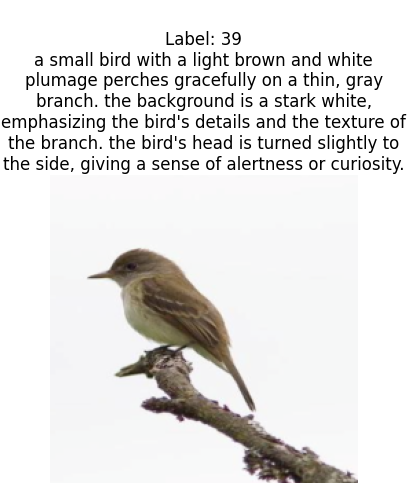

In [13]:
import matplotlib.pyplot as plt
import numpy as np

images, labels, captions = next(iter(train_loader))

img_tensor = images[0]
label_id = labels[0].item()
caption_text = captions[0]

def show_sample(img, title):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img.cpu().numpy()

    img = img.transpose((1, 2, 0))
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(title, wrap=True)
    plt.axis('off')
    plt.show()

show_sample(img_tensor, title=f"Label: {label_id}\n{caption_text}")

In [14]:
import torch.nn as nn
from torchvision import models

class BirdClassifierEfficientNetV2(nn.Module):
    def __init__(self, num_classes=200, freeze_backbone=True):
        super(BirdClassifierEfficientNetV2, self).__init__()
        
        # Load pre-trained EfficientNetV2 Small 
        self.model = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)
        
        if freeze_backbone:
            for param in self.model.parameters():
                param.requires_grad = False
                
        # Trong EfficientNetV2, classifer nằm ở self.model.classifier
        # Classifier thường là một nn.Sequential(nn.Dropout(...), nn.Linear(...))
        # Do đó ta sẽ lấy in_features của lớp Linear (index 1)
        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

    def get_optimizer(self, base_lr=1e-5, head_lr=1e-3, weight_decay=1e-4):
        
        # head param (lấy toàn bộ các parameters thuộc block classifier)
        head_params = list(self.model.classifier.parameters())
        head_param_ids = [id(p) for p in head_params]
        
        # backbone param
        backbone_params = [
            p for p in self.model.parameters()
            if id(p) not in head_param_ids and p.requires_grad
        ]
        
        optimizer = torch.optim.AdamW([
            {'params': backbone_params, 'lr': base_lr},
            {'params': head_params, 'lr': head_lr}
        ], weight_decay=weight_decay)
        
        return optimizer

    def predict_image(self, img_tensor, device):
        self.eval()
        with torch.no_grad():
            # Đảm bảo ảnh có batch dimension, ví dụ: từ [3, 224, 224] thành [1, 3, 224, 224]
            if len(img_tensor.shape) == 3:
                img_tensor = img_tensor.unsqueeze(0)
            
            img_tensor = img_tensor.to(device)
            outputs = self(img_tensor)
            
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            confidence, predicted_class = torch.max(probabilities, 1)
            
            return predicted_class.item(), confidence.item()

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BirdClassifierEfficientNetV2(num_classes=200, freeze_backbone=False).to(device)

optimizer = model.get_optimizer(base_lr=1e-5, head_lr=1e-3)

criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

In [ ]:
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

num_epochs = 50
patience = 3
epochs_no_improve = 0
best_test_acc = 0.0

history = {
    'train_loss': [], 'train_acc': [],
    'test_loss': [], 'test_acc': []
}

print("BẮT ĐẦU HUẤN LUYỆN...")

for epoch in range(num_epochs):
    # train
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    train_pbar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train", leave=False)

    for inputs, labels, _ in train_pbar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = 100 * correct_train / total_train

    # eval
    model.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0

    test_pbar = tqdm(test_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Test ", leave=False)

    with torch.no_grad():
        for inputs, labels, _ in test_pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    epoch_test_loss = test_loss / len(test_loader.dataset)
    epoch_test_acc = 100 * correct_test / total_test

    if scheduler is not None:
        scheduler.step()

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['test_loss'].append(epoch_test_loss)
    history['test_acc'].append(epoch_test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.2f}% | "
          f"Test Loss: {epoch_test_loss:.4f}, Acc: {epoch_test_acc:.2f}%")

    if epoch_test_acc > best_test_acc:
        print(f"Best acc: {epoch_test_acc:.2f}%. Đã lưu weights")
        best_test_acc = epoch_test_acc
        epochs_no_improve = 0
        # save
        torch.save(model.state_dict(), "best_effnetv2_cub.pth")
    else:
        epochs_no_improve += 1
        print(f"Test acc không tăng, early stopping: {epochs_no_improve}/{patience}")

        if epochs_no_improve >= patience:
            print(f"EARLY STOPPING. Đã dừng huấn luyện ở epoch {epoch+1}.")
            break

print("Hoàn thành quá trình huấn luyện!")

BẮT ĐẦU HUẤN LUYỆN...


Epoch [1/50] Train Loss: 3.7536, Acc: 23.59% | Test Loss: 8.2014, Acc: 48.29%
Best acc: 48.29%. Đã lưu weights


Epoch [2/50] Train Loss: 1.5881, Acc: 59.61% | Test Loss: 1.3404, Acc: 63.13%
Best acc: 63.13%. Đã lưu weights


Epoch [3/50] Train Loss: 0.9921, Acc: 73.62% | Test Loss: 1.0884, Acc: 69.59%
Best acc: 69.59%. Đã lưu weights


Epoch [4/50] Train Loss: 0.7175, Acc: 81.25% | Test Loss: 0.9586, Acc: 72.51%
Best acc: 72.51%. Đã lưu weights


...

Epoch [18/50] Train Loss: 0.0537, Acc: 98.88% | Test Loss: 0.8619, Acc: 78.22%
Test acc không tăng, early stopping: 1/3


Epoch [19/50] Train Loss: 0.0541, Acc: 98.85% | Test Loss: 0.8449, Acc: 78.86%
Best acc: 78.86%. Đã lưu weights


Epoch [20/50] Train Loss: 0.0428, Acc: 99.27% | Test Loss: 0.8565, Acc: 78.65%
Test acc không tăng, early stopping: 1/3


Epoch [21/50] Train Loss: 0.0421, Acc: 99.13% | Test Loss: 0.8714, Acc: 78.82%
Test acc không tăng, early stopping: 2/3


Epoch [22/50] Train Loss: 0.0396, Acc: 99.17% | Test Loss: 0.8785, Acc: 78.70%
Test acc không tăng, early stopping: 3/3
EARLY STOPPING. Đã dừng huấn luyện ở epoch 22.
Hoàn thành quá trình huấn luyện!


In [17]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm

def evaluate_retrieval_from_efficientnet(model, dataloader, device, k_values=[1, 3, 5, 7, 10, 20]):
    model.eval()
    all_features = []
    all_labels = []
    
    print("1. Đang trích xuất đặc trưng từ EfficientNet (Bỏ qua lớp phân loại)...")
    with torch.no_grad():
        for images, labels, _ in tqdm(dataloader, desc="Extracting"):
            images = images.to(device)
            
            # --- CÁCH LẤY ĐẶC TRƯNG CHO TORCHVISION EFFICIENTNET ---
            # 1. Chạy qua các lớp tích chập (Convolutional layers)
            features = model.model.features(images)
            # 2. Chạy qua lớp Global Average Pooling
            features = model.model.avgpool(features)
            # 3. Duỗi (Flatten) tensor thành vector 1 chiều (Kích thước [Batch, 1280])
            features = torch.flatten(features, 1)
            
            # Chuẩn hóa L2 để tính Cosine Similarity bằng Dot Product
            features = F.normalize(features, p=2, dim=1)
            
            all_features.append(features.cpu())
            all_labels.append(labels)
            
    all_features = torch.cat(all_features, dim=0) # [N, 1280]
    all_labels = torch.cat(all_labels, dim=0)     # [N]
    
    N = all_features.size(0)
    
    print("2. Đang tính ma trận khoảng cách (Cosine Similarity)...")
    similarity_matrix = torch.mm(all_features, all_features.t())
    
    # Bỏ qua việc tự so sánh với chính nó
    similarity_matrix.fill_diagonal_(-float('inf'))
    
    max_k = max(k_values)
    _, top_k_indices = similarity_matrix.topk(max_k, dim=1)
    top_k_labels = all_labels[top_k_indices]
    
    print("3. Đang tính toán Metrics (Precision, Recall, mAP)...")
    results = {k: {'Precision': 0.0, 'Recall': 0.0, 'mAP': 0.0} for k in k_values}
    
    for i in range(N):
        query_label = all_labels[i].item()
        retrieved_labels = top_k_labels[i].numpy()
        
        # Tổng số ảnh cùng class (không tính chính nó)
        total_relevant = (all_labels == query_label).sum().item() - 1 
        if total_relevant == 0:
            continue
            
        relevance_array = (retrieved_labels == query_label)
        
        for k in k_values:
            rel_k = relevance_array[:k]
            hits = rel_k.sum()
            
            results[k]['Precision'] += hits / k
            results[k]['Recall'] += hits / total_relevant
            
            if hits > 0:
                precisions = [rel_k[:j+1].sum() / (j+1) for j in range(k) if rel_k[j]]
                results[k]['mAP'] += sum(precisions) / min(k, total_relevant)
                
    for k in k_values:
        results[k]['Precision'] /= N
        results[k]['Recall'] /= N
        results[k]['mAP'] /= N
        
    return results

# Chạy đánh giá (Truyền đúng model EfficientNetV2 đã train)
k_vals = [1, 3, 5, 7, 10, 20]
metrics = evaluate_retrieval_from_efficientnet(model, test_loader, device, k_values=k_vals)

# In kết quả
print("\n" + "="*65)
print(f"{'K':<5} | {'Precision@K':<15} | {'Recall@K':<15} | {'mAP@K':<15}")
print("-" * 65)
for k in k_vals:
    p = metrics[k]['Precision']
    r = metrics[k]['Recall']
    m = metrics[k]['mAP']
    print(f"{k:<5} | {p:<15.4f} | {r:<15.4f} | {m:<15.4f}")
print("="*65)

1. Đang trích xuất đặc trưng từ EfficientNet (Bỏ qua lớp phân loại)...


Extracting: 100%|██████████| 182/182 [00:23<00:00,  7.65it/s]


2. Đang tính ma trận khoảng cách (Cosine Similarity)...
3. Đang tính toán Metrics (Precision, Recall, mAP)...

K     | Precision@K     | Recall@K        | mAP@K          
-----------------------------------------------------------------
1     | 0.7081          | 0.0254          | 0.7081         
3     | 0.6720          | 0.0721          | 0.6337         
5     | 0.6463          | 0.1156          | 0.5909         
7     | 0.6238          | 0.1560          | 0.5574         
10    | 0.5923          | 0.2114          | 0.5157         
20    | 0.5055          | 0.3594          | 0.4143         
